# Machine Learning Lab: Iris Classification with LDA and MLP Classifier Comparison

**Name: Maniarasan J**

**Registration Number: 2547261** 

**Class: 4 MCAB**

**Lab: ETE lab**


## Imports

These are the libraries needed for data handling, visualization, and building the models. A fixed random state is set so that the results stay the same every time the notebook is run.

In [1]:
# Libraries for data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules for datasets, splitting, models, and evaluation
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Keep results consistent across runs
RANDOM_STATE = 42

# Question 1: Iris Classification and LDA

In this part of the lab, the Iris dataset is used to compare classification with and without dimensionality reduction. First, a K-Nearest Neighbors (KNN) classifier is trained on the original features. Then, it's compared to a pipeline where Linear Discriminant Analysis (LDA) is used to reduce the features before classification.

The main objectives of this experiment are to:
- load and inspect the Iris dataset,
- apply feature scaling,
- compare classification with and without LDA,
- understand how dimensionality reduction affects classification.

## 1. Load the Dataset

The Iris dataset contains 150 flower samples from three species. Each sample has four numerical measurements: sepal length, sepal width, petal length, and petal width. We load it here and look at some basic details to understand the data before building models.

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Number of classes: 3
Target names: ['setosa' 'versicolor' 'virginica']

Class Distribution:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing values in dataset:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
target_name          0
dtype: int64

First five rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


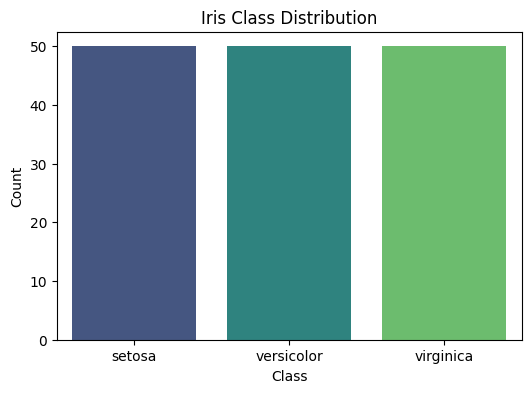

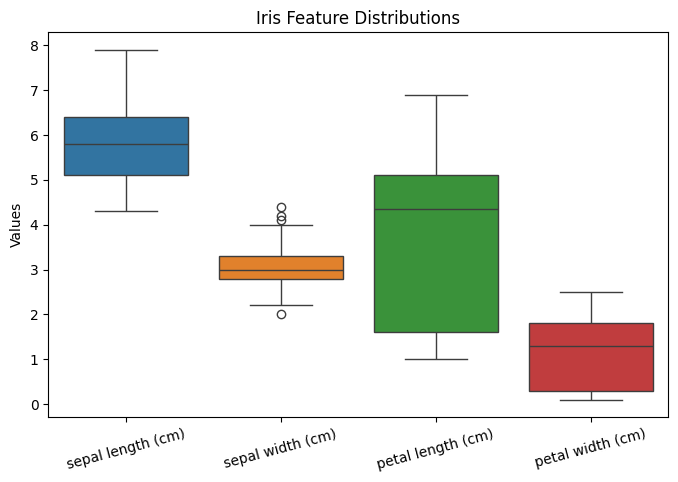

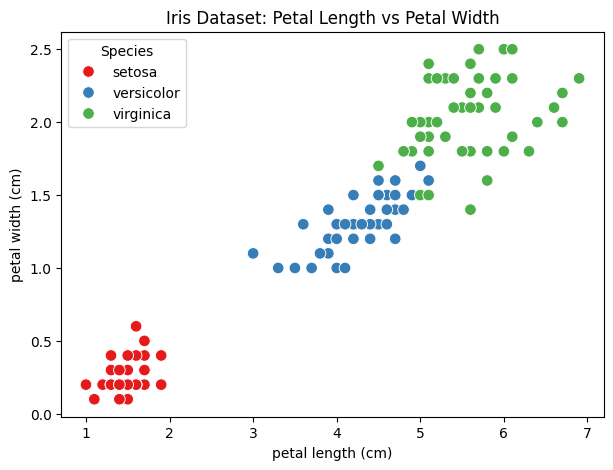

In [2]:
data = load_iris()

X = data.data
y = data.target

# Put data into a DataFrame to easily view it
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Feature names:", data.feature_names)
print("Number of classes:", len(data.target_names))
print("Target names:", data.target_names)

print("\nClass Distribution:")
print(df['target_name'].value_counts())

print("\nMissing values in dataset:")
print(df.isnull().sum())

print("\nFirst five rows:")
display(df.head())

print("\nDescriptive Statistics:")
display(df.describe())

# Plot how many samples belong to each class
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target_name', order=data.target_names, hue='target_name', legend=False, palette='viridis')
plt.title('Iris Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Show the spread of each feature
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.drop(columns=['target', 'target_name']))
plt.title('Iris Feature Distributions')
plt.ylabel('Values')
plt.xticks(rotation=15)
plt.show()

# Visualize two features to see how the classes group together
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='target_name', palette='Set1', s=70)
plt.title('Iris Dataset: Petal Length vs Petal Width')
plt.legend(title='Species')
plt.show()

## 2. Data Preprocessing

The data is divided into training and test sets so that the final model can be checked on data it has not seen during training. Stratification keeps the class proportions similar in both sets.

In [3]:
# Split 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (120, 4)
Testing set shape: (30, 4)


## 3. Original Feature Pipeline

Since the four features are measured on different scales, they are standardized before training. This puts them on a comparable scale and is especially useful for distance-based models like KNN. A Pipeline is used to group the scaler and the classifier together.

In [4]:
# Pipeline 1: Scale features then apply KNN
original_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

## 4. LDA Pipeline

LDA uses the class labels to find directions that separate the classes as much as possible. Iris has 4 features and 3 classes, so LDA can produce at most 2 components (number of classes minus 1). In this pipeline, the 4 features are reduced to 2 before being passed to the classifier.

In [5]:
# Pipeline 2: Scale features, reduce with LDA, then apply KNN
lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2)),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

## 5. Cross-Validation Results

Five-fold cross-validation is used so that the training data is evaluated across five different splits. This gives a more reliable estimate of how the models perform compared to just using a single split.

In [6]:
# Setup 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Evaluate the original pipeline on training data
original_cv_scores = cross_val_score(
    original_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

# Evaluate the LDA pipeline on training data
lda_cv_scores = cross_val_score(
    lda_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("Original Features:")
for i, score in enumerate(original_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"Mean: {original_cv_scores.mean():.4f}")
print(f"Std: {original_cv_scores.std():.4f}\n")

print("LDA:")
for i, score in enumerate(lda_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"Mean: {lda_cv_scores.mean():.4f}")
print(f"Std: {lda_cv_scores.std():.4f}\n")

# Show results in a table
results_df = pd.DataFrame({
    "Method": ["Original Features", "LDA Features"],
    "Features Used": [4, 2],
    "Mean CV Accuracy": [original_cv_scores.mean(), lda_cv_scores.mean()],
    "Std CV Accuracy": [original_cv_scores.std(), lda_cv_scores.std()]
})

display(results_df)

Original Features:
Fold 1: 0.9583
Fold 2: 1.0000
Fold 3: 0.9583
Fold 4: 0.9167
Fold 5: 0.9583
Mean: 0.9583
Std: 0.0264

LDA:
Fold 1: 0.9583
Fold 2: 1.0000
Fold 3: 1.0000
Fold 4: 0.9583
Fold 5: 0.9167
Mean: 0.9667
Std: 0.0312



,Method,Features Used,Mean CV Accuracy,Std CV Accuracy
0,Original Features,4,0.958333,0.026352
1,LDA Features,2,0.966667,0.031180


## 6. Test Results

The models are now trained on the full training set and evaluated on the test set to see how well they handle unseen data. The confusion matrix shows how many samples from each class were predicted correctly and where the model made mistakes. The diagonal values represent correct predictions.

Original Features Pipeline Test Accuracy: 0.9333
LDA Pipeline Test Accuracy: 1.0000


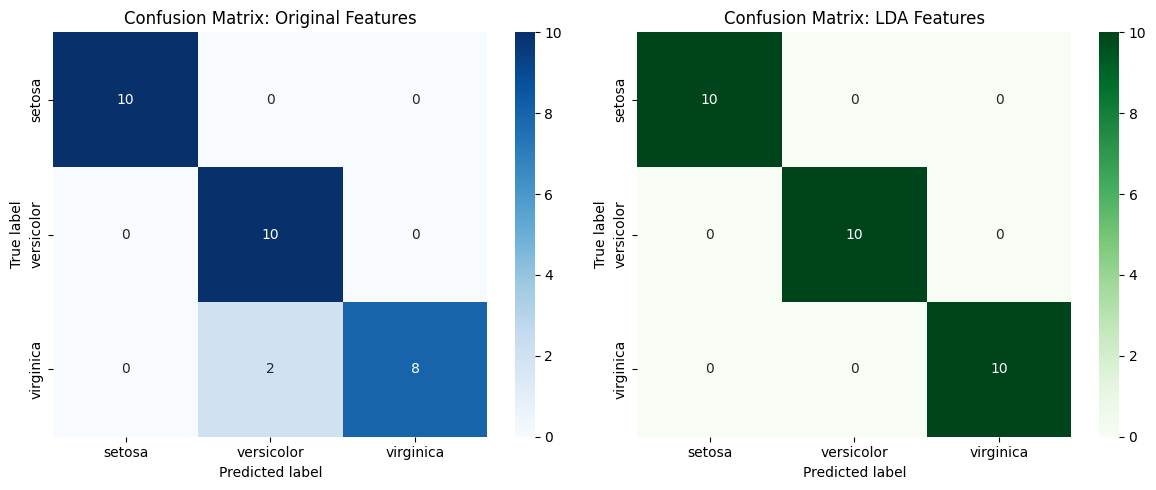

In [7]:
# Train both pipelines
original_pipeline.fit(X_train, y_train)
lda_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_original = original_pipeline.predict(X_test)
y_pred_lda = lda_pipeline.predict(X_test)

# Calculate final test accuracies
acc_original = accuracy_score(y_test, y_pred_original)
acc_lda = accuracy_score(y_test, y_pred_lda)

print(f"Original Features Pipeline Test Accuracy: {acc_original:.4f}")
print(f"LDA Pipeline Test Accuracy: {acc_lda:.4f}")

# Generate confusion matrices
cm_original = confusion_matrix(y_test, y_pred_original)
cm_lda = confusion_matrix(y_test, y_pred_lda)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot confusion matrix for original features
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix: Original Features')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Plot confusion matrix for LDA features
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Greens', 
            xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[1])
axes[1].set_title('Confusion Matrix: LDA Features')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

## 7. LDA Visualization

Here, the LDA transformation is applied to the training data to show how it separates the three Iris classes in 2D space.

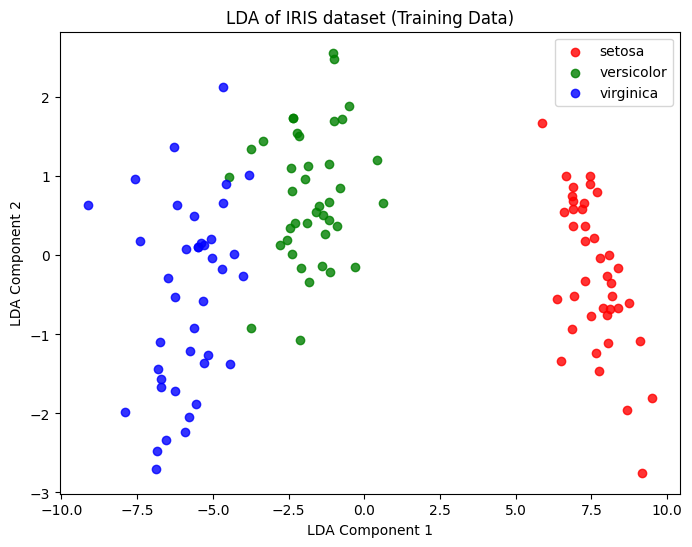

In [8]:
# Get the scaled and reduced data from the LDA pipeline
X_train_scaled = lda_pipeline.named_steps['scaler'].transform(X_train)
X_train_lda = lda_pipeline.named_steps['lda'].transform(X_train_scaled)

# Plot the 2D LDA projection
plt.figure(figsize=(8, 6))
colors = ['r', 'g', 'b']
for color, i, target_name in zip(colors, [0, 1, 2], data.target_names):
    plt.scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], 
                alpha=.8, color=color, label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('LDA of IRIS dataset (Training Data)')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.show()

## 8. Conclusion

From the results below, we can compare how the original features and the LDA features performed. The reduced representation can make the downstream classifier simpler. LDA may improve classification when the reduced components preserve useful class information, but it does not guarantee better accuracy in every dataset.

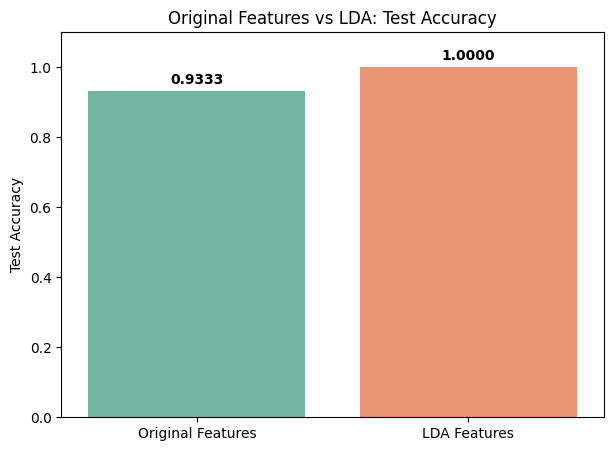

In this experiment, the LDA-based pipeline performed better than the original-feature pipeline on the test set. LDA successfully reduced the four original features to two components, which means the KNN classifier had to perform distance calculations in a smaller space. This can reduce computational and memory requirements, even though fitting the LDA itself takes some computation.

In [9]:
from IPython.display import Markdown

original_cv_mean = original_cv_scores.mean()
lda_cv_mean = lda_cv_scores.mean()
original_test_acc = acc_original
lda_test_acc = acc_lda

# Plot test accuracy comparison
plt.figure(figsize=(7, 5))
methods = ['Original Features', 'LDA Features']
test_accuracies = [original_test_acc, lda_test_acc]

sns.barplot(x=methods, y=test_accuracies, hue=methods, legend=False, palette='Set2')
plt.title('Original Features vs LDA: Test Accuracy')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.1)
for i, v in enumerate(test_accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

# Generate natural conclusion text based on actual results
if lda_test_acc > original_test_acc:
    perf_text = "the LDA-based pipeline performed better than the original-feature pipeline on the test set."
elif lda_test_acc == original_test_acc:
    perf_text = "the LDA-based pipeline performed similarly to the original-feature pipeline on the test set."
else:
    perf_text = "the original-feature pipeline performed better than the LDA-based pipeline on the test set."

conclusion = f"""In this experiment, {perf_text} LDA successfully reduced the four original features to two components, which means the KNN classifier had to perform distance calculations in a smaller space. This can reduce computational and memory requirements, even though fitting the LDA itself takes some computation."""
display(Markdown(conclusion))

# Question 2: MLP Classifier Comparison

The main objective of this experiment is to compare two Multi-Layer Perceptron (MLP) architectures using cross-validation. An MLP is a feed-forward neural network that learns patterns by passing the input through one or more hidden layers. The original Iris features are used for this part, completely separate from the previous LDA experiment.

## 1. MLP Architectures

The data is split again for this independent experiment. Then, two different neural network models are built:
- **Model 1:** This model uses one hidden layer containing 8 neurons.
- **Model 2:** This model has two hidden layers. The first contains 8 neurons and the second contains 4 neurons.

In [10]:
# Create a fresh train-test split for the MLP experiment
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

Both models use the 'adam' solver and are scaled before training so they can converge properly.

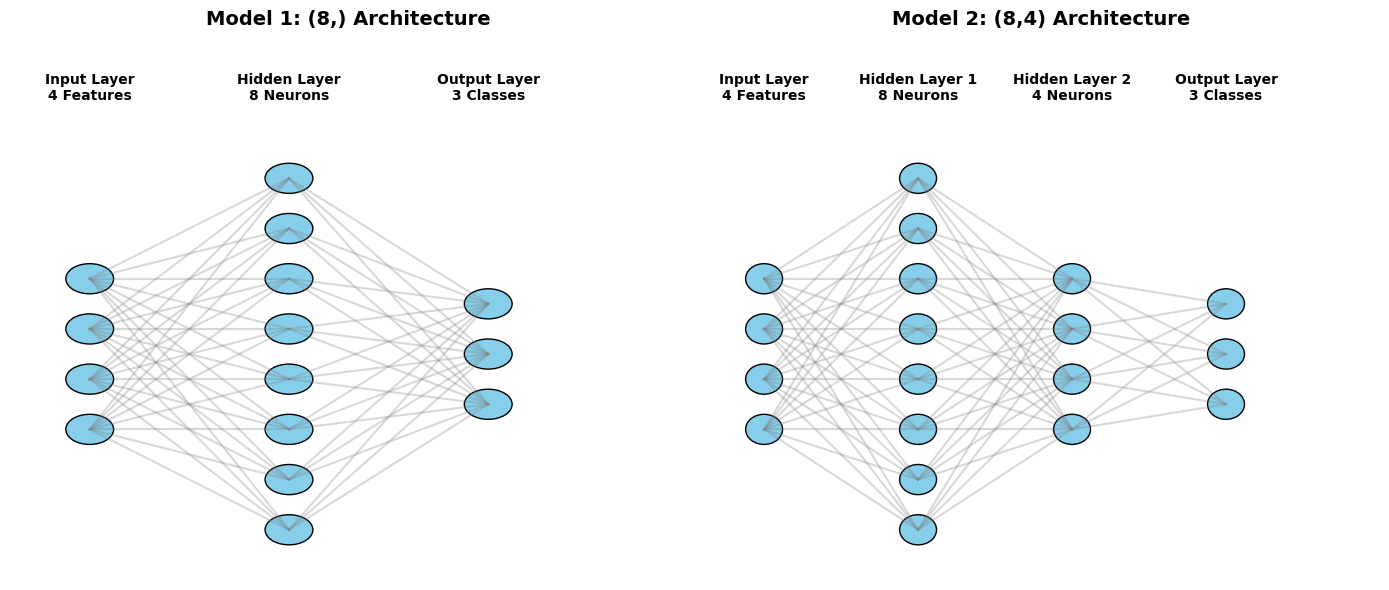

In [11]:
# MLP ARCHITECTURE DIAGRAM
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def draw_mlp(ax, layers, title, layer_labels):
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    v_spacing = 1.0
    h_spacing = 2.5
    
    node_positions = []
    max_nodes = max(layers)
    
    for i, n_nodes in enumerate(layers):
        layer_nodes = []
        y_offset = (max_nodes - n_nodes) * v_spacing / 2
        
        # Draw layer label above the layer
        ax.text(i * h_spacing, max_nodes * v_spacing + 0.5, layer_labels[i], 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
                
        for j in range(n_nodes):
            x = i * h_spacing
            y = y_offset + j * v_spacing
            circle = patches.Circle((x, y), 0.3, fill=True, color='skyblue', ec='black')
            ax.add_patch(circle)
            layer_nodes.append((x, y))
            
        node_positions.append(layer_nodes)
        
    for i in range(len(layers) - 1):
        for start_node in node_positions[i]:
            for end_node in node_positions[i+1]:
                ax.plot([start_node[0], end_node[0]], [start_node[1], end_node[1]], 'gray', alpha=0.3)
                
    ax.set_xlim(-1, len(layers) * h_spacing)
    ax.set_ylim(-1, max_nodes * v_spacing + 1.5)

draw_mlp(axes[0], [4, 8, 3], "Model 1: (8,) Architecture", 
         ["Input Layer\n4 Features", "Hidden Layer\n8 Neurons", "Output Layer\n3 Classes"])
draw_mlp(axes[1], [4, 8, 4, 3], "Model 2: (8,4) Architecture", 
         ["Input Layer\n4 Features", "Hidden Layer 1\n8 Neurons", "Hidden Layer 2\n4 Neurons", "Output Layer\n3 Classes"])

plt.tight_layout()
plt.show()

# Setup MLP 1
mlp1_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(8,),
        solver="adam",
        random_state=RANDOM_STATE,
        max_iter=2000
    ))
])

# Setup MLP 2
mlp2_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(8, 4),
        solver="adam",
        random_state=RANDOM_STATE,
        max_iter=2000
    ))
])

## 2. Cross-Validation

Both architectures are evaluated using 5-fold cross-validation on the training set.

MODEL 1 (8,):
Fold 1: 0.9583
Fold 2: 1.0000
Fold 3: 0.9583
Fold 4: 0.9583
Fold 5: 0.9167
Mean: 0.9583
Std: 0.0264

MODEL 2 (8,4):
Fold 1: 0.9583
Fold 2: 1.0000
Fold 3: 0.9583
Fold 4: 0.9583
Fold 5: 0.9167
Mean: 0.9583
Std: 0.0264

Cross-Validation Fold Accuracies:


,Fold,"MLP (8,)","MLP (8,4)"
0,1,0.958333,0.958333
1,2,1.000000,1.000000
2,3,0.958333,0.958333
3,4,0.958333,0.958333
4,5,0.916667,0.916667


,Model,Architecture,Mean CV Accuracy,Std CV Accuracy
0,MLP 1,"(8,)",0.958333,0.026352
1,MLP 2,"(8, 4)",0.958333,0.026352


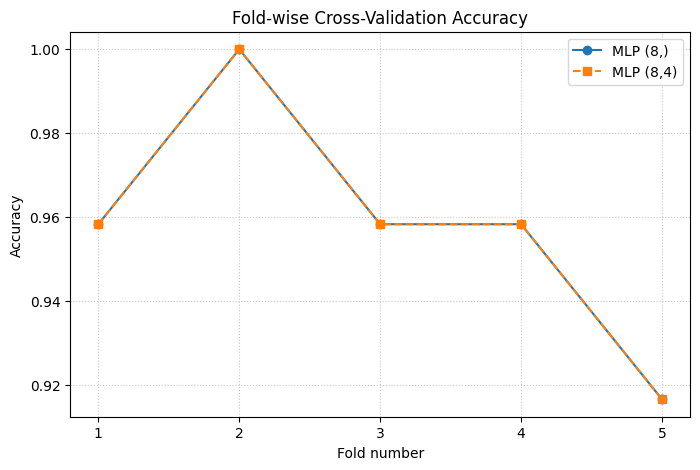

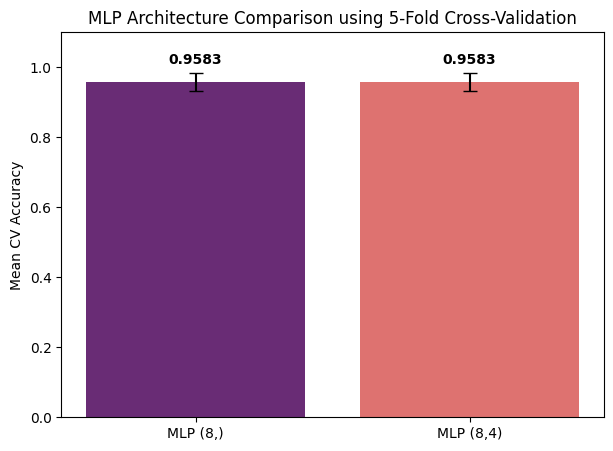

In [12]:
# Setup 5-fold CV for MLP
cv_mlp = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Evaluate MLP 1
mlp1_cv_scores = cross_val_score(
    mlp1_pipeline,
    X_train_mlp,
    y_train_mlp,
    cv=cv_mlp,
    scoring="accuracy"
)

# Evaluate MLP 2
mlp2_cv_scores = cross_val_score(
    mlp2_pipeline,
    X_train_mlp,
    y_train_mlp,
    cv=cv_mlp,
    scoring="accuracy"
)

# Visibly display folds
print("MODEL 1 (8,):")
for i, score in enumerate(mlp1_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"Mean: {mlp1_cv_scores.mean():.4f}")
print(f"Std: {mlp1_cv_scores.std():.4f}\n")

print("MODEL 2 (8,4):")
for i, score in enumerate(mlp2_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")
print(f"Mean: {mlp2_cv_scores.mean():.4f}")
print(f"Std: {mlp2_cv_scores.std():.4f}\n")

# Fold-accuracy table
fold_df = pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "MLP (8,)": mlp1_cv_scores,
    "MLP (8,4)": mlp2_cv_scores
})
print("Cross-Validation Fold Accuracies:")
display(fold_df)

# Summary table
mlp_results_df = pd.DataFrame({
    "Model": ["MLP 1", "MLP 2"],
    "Architecture": ["(8,)", "(8, 4)"],
    "Mean CV Accuracy": [mlp1_cv_scores.mean(), mlp2_cv_scores.mean()],
    "Std CV Accuracy": [mlp1_cv_scores.std(), mlp2_cv_scores.std()]
})
display(mlp_results_df)

# Plot CV fold comparison
plt.figure(figsize=(8, 5))
folds = np.arange(1, 6)
plt.plot(folds, mlp1_cv_scores, marker='o', label='MLP (8,)', linestyle='-')
plt.plot(folds, mlp2_cv_scores, marker='s', label='MLP (8,4)', linestyle='--')
plt.title('Fold-wise Cross-Validation Accuracy')
plt.xlabel('Fold number')
plt.ylabel('Accuracy')
plt.xticks(folds)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Plot Mean CV comparison
plt.figure(figsize=(7, 5))
models = ['MLP (8,)', 'MLP (8,4)']
means = [mlp1_cv_scores.mean(), mlp2_cv_scores.mean()]
stds = [mlp1_cv_scores.std(), mlp2_cv_scores.std()]

sns.barplot(x=models, y=means, hue=models, legend=False, palette='magma', capsize=0.1)
plt.errorbar(x=[0, 1], y=means, yerr=stds, fmt='none', c='black', capsize=5)
plt.title('MLP Architecture Comparison using 5-Fold Cross-Validation')
plt.ylabel('Mean CV Accuracy')
plt.ylim(0, 1.1)
for i, v in enumerate(means):
    plt.text(i, v + 0.05, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

## 3. Model Selection

The model with the better mean cross-validation accuracy is selected. The test set is kept separate and is used only for the final evaluation.

In [13]:
mlp1_cv_mean = mlp1_cv_scores.mean()
mlp2_cv_mean = mlp2_cv_scores.mean()

if mlp1_cv_mean > mlp2_cv_mean:
    best_model_name = "Model 1 (8,)"
    best_model = mlp1_pipeline
    best_cv_mean = mlp1_cv_mean
    best_cv_std = mlp1_cv_scores.std()
elif mlp2_cv_mean > mlp1_cv_mean:
    best_model_name = "Model 2 (8, 4)"
    best_model = mlp2_pipeline
    best_cv_mean = mlp2_cv_mean
    best_cv_std = mlp2_cv_scores.std()
else:
    # Handle tie
    best_model_name = "Model 1 (8,)"
    best_model = mlp1_pipeline
    best_cv_mean = mlp1_cv_mean
    best_cv_std = mlp1_cv_scores.std()
    print("Both architectures achieved the same mean cross-validation accuracy. In this case, the simpler one is selected because it uses fewer hidden layers.\n")

print("Selected Model:", best_model_name)
print(f"Best CV Mean Accuracy: {best_cv_mean:.4f}")

Both architectures achieved the same mean cross-validation accuracy. In this case, the simpler one is selected because it uses fewer hidden layers.

Selected Model: Model 1 (8,)
Best CV Mean Accuracy: 0.9583


## 4. Test Evaluation

The selected model is now trained on the full training set and tested to see its final performance. The training loss curve shows how the model improved over time during training.

Selected Architecture: Model 1 (8,)
Mean CV Accuracy: 0.9583
CV Standard Deviation: 0.0264
Selected Model Test Accuracy: 0.9333

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



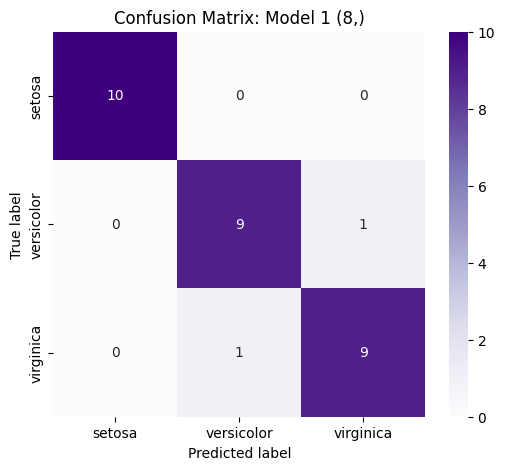

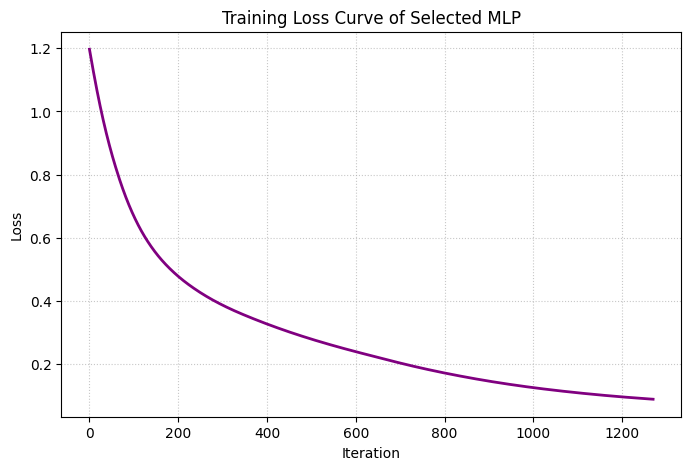

In [14]:
# Train the selected model on the training data
best_model.fit(X_train_mlp, y_train_mlp)

# Test it on the test data
y_pred_mlp = best_model.predict(X_test_mlp)

# Calculate final test accuracy
mlp_test_acc = accuracy_score(y_test_mlp, y_pred_mlp)

print(f"Selected Architecture: {best_model_name}")
print(f"Mean CV Accuracy: {best_cv_mean:.4f}")
print(f"CV Standard Deviation: {best_cv_std:.4f}")
print(f"Selected Model Test Accuracy: {mlp_test_acc:.4f}")

# Show detailed classification metrics
print("\nClassification Report:\n")
print(classification_report(y_test_mlp, y_pred_mlp, target_names=data.target_names))

# Generate the confusion matrix
cm_mlp = confusion_matrix(y_test_mlp, y_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

# Show the training loss curve for the selected neural network
selected_mlp = best_model.named_steps["mlp"]
if hasattr(selected_mlp, 'loss_curve_'):
    plt.figure(figsize=(8, 5))
    plt.plot(selected_mlp.loss_curve_, color='purple', linewidth=2)
    plt.title('Training Loss Curve of Selected MLP')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

## 5. Conclusion

In [15]:
# Generate natural conclusion for Question 2
if mlp1_cv_mean == mlp2_cv_mean:
    comp_text = "both architectures showed similar cross-validation performance, so the simpler architecture was selected."
elif mlp1_cv_mean > mlp2_cv_mean:
    comp_text = "the simpler architecture with one hidden layer performed better during cross-validation and was selected."
else:
    comp_text = "the deeper architecture with two hidden layers performed better during cross-validation and was selected."

conclusion_2 = f"""For the MLP comparison, {comp_text} The selected model achieved a test accuracy of {mlp_test_acc:.4f}. The confusion matrix shows where the neural network made correct predictions and where it made mistakes."""
display(Markdown(conclusion_2))

For the MLP comparison, both architectures showed similar cross-validation performance, so the simpler architecture was selected. The selected model achieved a test accuracy of 0.9333. The confusion matrix shows where the neural network made correct predictions and where it made mistakes.

In [16]:
# Show a final summary of the whole lab
final_summary = f"""# FINAL LAB SUMMARY

### QUESTION 1:

| Pipeline | Features | Mean CV Accuracy | Test Accuracy |
|----------|----------|------------------|---------------|
| Original | 4 | {original_cv_mean:.4f} | {original_test_acc:.4f} |
| LDA | 2 | {lda_cv_mean:.4f} | {lda_test_acc:.4f} |

### QUESTION 2:

| Model | Architecture | Mean CV Accuracy | Std CV Accuracy |
|------|--------------|------------------|-----------------|
| MLP 1 | (8,) | {mlp1_cv_mean:.4f} | {mlp1_cv_scores.std():.4f} |
| MLP 2 | (8,4) | {mlp2_cv_mean:.4f} | {mlp2_cv_scores.std():.4f} |

Selected MLP:
{best_model_name}

Selected MLP Test Accuracy:
{mlp_test_acc:.4f}
"""
display(Markdown(final_summary))

# FINAL LAB SUMMARY

### QUESTION 1:

| Pipeline | Features | Mean CV Accuracy | Test Accuracy |
|----------|----------|------------------|---------------|
| Original | 4 | 0.9583 | 0.9333 |
| LDA | 2 | 0.9667 | 1.0000 |

### QUESTION 2:

| Model | Architecture | Mean CV Accuracy | Std CV Accuracy |
|------|--------------|------------------|-----------------|
| MLP 1 | (8,) | 0.9583 | 0.0264 |
| MLP 2 | (8,4) | 0.9583 | 0.0264 |

Selected MLP:
Model 1 (8,)

Selected MLP Test Accuracy:
0.9333
